# 🛒 Sales Forecasting & Customer Insights

## 📋 Introduction

This notebook performs an exploratory data analysis (EDA) on the "Sample Superstore" dataset, simulating an online retail business scenario.  

The goal is to identify sales trends, uncover business opportunities, and generate actionable insights based on the available data.

In [2]:
# 📚 Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings for visualization
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

In [3]:
# 📂 Load dataset

data_path = '../data/superstore_sales.csv' 
df = pd.read_csv(data_path, encoding= 'unicode_escape')

# Show first 5 rows
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
# 🔎 Quick exploration

# Shape of dataset
print(f"Dataset shape: {df.shape}")

# Data types and non-null values
df.info()

# Basic statistics
df.describe()

Dataset shape: (2823, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2    

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


## 🧹 2. Data Cleaning

In this section, we will clean the dataset to ensure the quality of our analysis.  
We will handle missing values, remove duplicate records, correct data types, and engineer new features that will support deeper insights.

### 2.1 Handling Missing Values

We first check for missing values across all features.  
Based on the analysis:

- `ADDRESSLINE2` contains a high number of missing entries and represents secondary address details, which are not critical for business insights. ➔ It will be **dropped**.
- `TERRITORY` contains a significant amount of missing data and overlaps with `COUNTRY`. ➔ It will be **dropped**.
- `STATE` has missing values primarily for international cities. ➔ A customized filling strategy will be applied.
- `POSTALCODE` has a few missing entries. ➔ A simple strategy will be applied to maintain consistency.

Columns with zero missing values will remain unchanged.

In [5]:
# 🔎 Check for missing values
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

#### 2.1.1 Dropping ADDRESSLINE2 and TERRITORY

Both `ADDRESSLINE2` and `TERRITORY` were dropped from the dataset:  
- `ADDRESSLINE2` provides secondary address information not relevant for business insights.
- `TERRITORY` is redundant with `COUNTRY` and has too many missing values.

In [6]:
# 🚮 Drop 'ADDRESSLINE2' as it provides secondary details not necessary for the analysis
df.drop(columns=['ADDRESSLINE2'], inplace=True)

# 🔍 Unique values in 'TERRITORY'
print(df['TERRITORY'].unique())

# 🔍 Unique values in 'COUNTRY'
print(df['COUNTRY'].unique())

[nan 'EMEA' 'APAC' 'Japan']
['USA' 'France' 'Norway' 'Australia' 'Finland' 'Austria' 'UK' 'Spain'
 'Sweden' 'Singapore' 'Canada' 'Japan' 'Italy' 'Denmark' 'Belgium'
 'Philippines' 'Germany' 'Switzerland' 'Ireland']


In [7]:
# 🚮 Drop 'TERRITORY' column because it's not relevant to the analysis
df.drop(columns=['TERRITORY'], inplace=True)

In [8]:
# 🔍 Find unique cities where STATE is missing

cities_with_missing_state = df[df['STATE'].isnull()]['CITY'].unique()

print(f"Total cities with missing STATE: {len(cities_with_missing_state)}")
print(cities_with_missing_state)

Total cities with missing STATE: 39
['Reims' 'Paris' 'Lille' 'Bergen' 'Nantes' 'Helsinki' 'Stavern' 'Salzburg'
 'Liverpool' 'Madrid' 'Lule' 'Singapore' 'Lyon' 'Torino' 'Boras'
 'Versailles' 'Kobenhavn' 'London' 'Toulouse' 'Barcelona' 'Bruxelles'
 'Oulu' 'Graz' 'Makati City' 'Marseille' 'Koln' 'Gensve' 'Reggio Emilia'
 'Frankfurt' 'Espoo' 'Dublin' 'Manchester' 'Aaarhus' 'Sevilla'
 'Strasbourg' 'Oslo' 'Bergamo' 'Munich' 'Charleroi']


#### 2.1.2 Strategy for Missing STATE Values

Since most missing `STATE` entries correspond to international cities outside the United States,  
and these regions typically do not have a state system equivalent to the U.S.,  
we decided to replace missing `STATE` values with the corresponding `COUNTRY` name.

This ensures that all records have a consistent geographical field without compromising data quality.

In [9]:
# 🛠️ Fill missing STATE based on COUNTRY for international cities

# If STATE is missing, assign COUNTRY instead
df['STATE'] = df.apply(lambda x: x['COUNTRY'] if pd.isnull(x['STATE']) else x['STATE'], axis=1)

# Check if there are still any missing values in STATE
df['STATE'].isnull().sum()

np.int64(0)

#### 2.1.3 Handling Missing Values in POSTALCODE

Since `POSTALCODE` represents a textual identifier rather than a numeric field,  
we converted it to string format.  
Missing postal codes were replaced with the label `'Missing'` to maintain data consistency without introducing synthetic information.

In [10]:
# 🛠️ Convert POSTALCODE to string
df['POSTALCODE'] = df['POSTALCODE'].astype(str)

# 🛠️ Replace missing postal codes with 'Missing'
df['POSTALCODE'] = df['POSTALCODE'].replace('nan', 'Missing')

In [11]:
# 🔎 Check for missing values again
df.isnull().sum()

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

#### ✅ Summary of Missing Value Treatment

At the end of the missing value treatment process:

- `ADDRESSLINE2` and `TERRITORY` were dropped.
- Missing `STATE` entries were filled using the corresponding `COUNTRY` name.
- `POSTALCODE` missing entries were labeled as `'Missing'` after converting the column to string type.
- All other columns had complete data and required no special treatment.

🔵 The dataset now has **no missing values** and is ready for duplicate checking and further analysis.

### 2.2 Handling Duplicate Records

Duplicate records can lead to inaccurate analyses by over-representing certain data points.  
In this section, we will identify and remove any duplicate rows from the dataset to ensure data integrity.

In [12]:
# 🔎 Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_rows}")

# 🚮 Remove duplicate rows if any
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows have been removed.")
else:
    print("No duplicate rows found.")

Total duplicate rows found: 0
No duplicate rows found.


#### 2.2.1 Duplicate Removal Summary

After checking for duplicate records:

- No duplicate rows were found in the dataset.  

🔵 The dataset is now free of duplicates and ready for further processing.

### 2.3 Correcting and Optimizing Data Types

Accurate data types are essential for correct analysis and visualization.  
In this section, we ensure that key columns such as dates and categorical fields have the appropriate formats.  
Additionally, selected categorical columns will be optimized using the `category` data type to improve memory usage and performance.

In [13]:
# 🗓️ Ensure 'ORDERDATE' is datetime
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# 🛒 Convert selected columns to string type (categorical-like fields)
categorical_columns_to_string = [
    'STATUS', 'PRODUCTLINE', 'PRODUCTCODE', 'CUSTOMERNAME', 
    'PHONE', 'ADDRESSLINE1', 'CITY', 'STATE', 'COUNTRY', 
    'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE'
]

for col in categorical_columns_to_string:
    df[col] = df[col].astype(str)

# 🔢 Ensure numeric columns are numeric type
numeric_columns = [
    'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 
    'SALES', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'MSRP'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#### 2.3.1 Data Types Correction Summary

- `ORDERDATE` was successfully converted to datetime format.
- Categorical fields were cast to string type to ensure consistent textual processing.
- Numeric fields were cast to numeric types to facilitate calculations and aggregations.

🔵 The dataset now has consistent and accurate data types across all key features.

#### 2.3.2 Optimization: Converting Columns to 'Category' Dtype

To optimize memory usage and improve performance during data operations,  
selected categorical columns (`STATUS`, `PRODUCTLINE`, `COUNTRY`, `STATE`, `DEALSIZE`)  
were converted to the `category` data type.

This transformation reduces memory footprint and speeds up operations like grouping and filtering.

In [14]:
# 🛠️ Convert selected columns to 'category' dtype for optimization

category_columns = ['STATUS', 'PRODUCTLINE', 'COUNTRY', 'STATE', 'DEALSIZE']

for col in category_columns:
    df[col] = df[col].astype('category')

### 2.4 Feature Engineering

Feature engineering allows us to extract new variables that can provide additional insights and improve the depth of our analysis.  
In this section, we will create new features such as the month and year of orders, and the delivery time in days.

In [15]:
# 🛠️ Create new features

# Extract Month and Year from ORDERDATE
df['ORDER_MONTH'] = df['ORDERDATE'].dt.month
df['ORDER_YEAR'] = df['ORDERDATE'].dt.year

#### 2.4.1 Summary of New Features

- `ORDER_MONTH`: Month extracted from the `ORDERDATE`.
- `ORDER_YEAR`: Year extracted from the `ORDERDATE`.

🔵 These new features will allow us to perform time-based trend analysis and evaluate seasonal sales patterns.

### 🔎 2.5 Data Quality Validation Before Exploratory Data Analysis (EDA)

Before proceeding with visual exploratory data analysis, we conducted a data quality validation to ensure the accuracy and reliability of our insights.  
This process included:

---

#### 2.5.1 Improved Outlier Detection

We improved the outlier detection process by:

- Enhancing the aesthetic quality of boxplots to facilitate visual interpretation.
- Applying an objective mathematical method (Interquartile Range, IQR) to detect outliers systematically.

Outliers are defined as any value lying outside the range:
`[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`

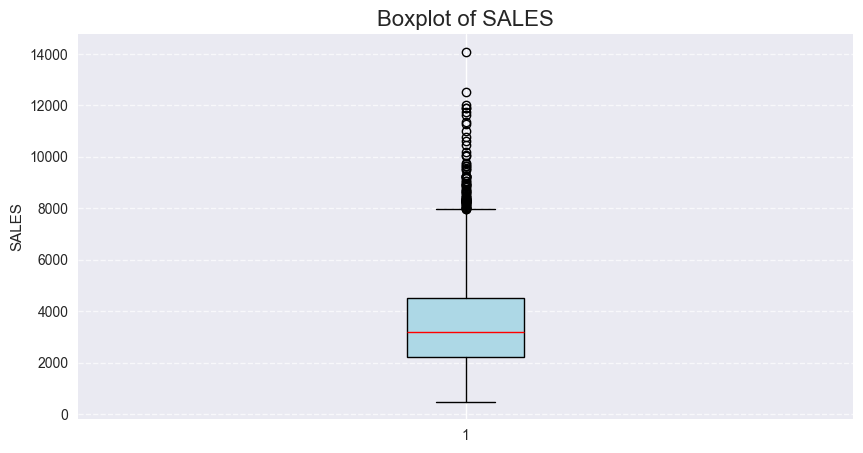

Outliers detected in SALES: 81 rows


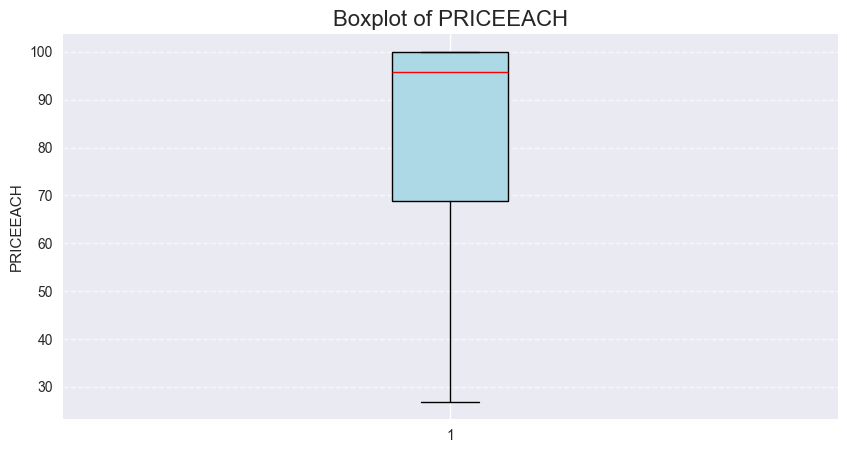

Outliers detected in PRICEEACH: 0 rows


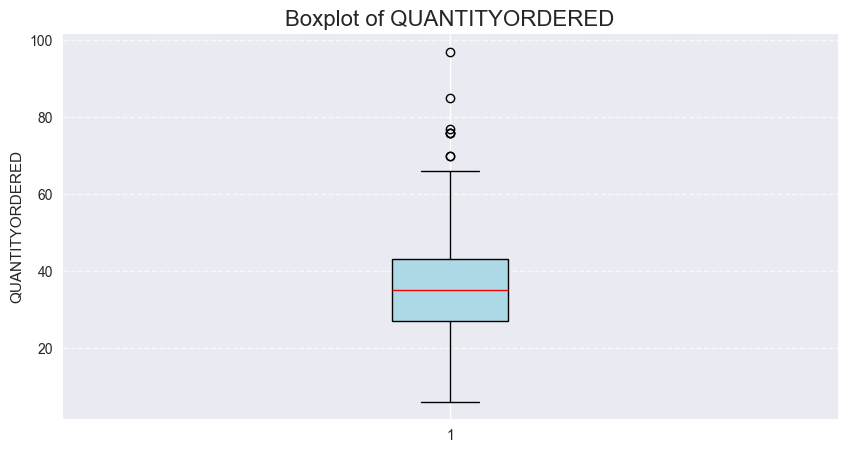

Outliers detected in QUANTITYORDERED: 8 rows


In [16]:
# 📦 Quick boxplot to detect outliers in SALES, PRICEEACH, QUANTITYORDERED

def plot_boxplot(feature, df):
    plt.figure(figsize=(10,5))
    plt.boxplot(df[feature], patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red'),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))
    plt.title(f'Boxplot of {feature}', fontsize=16)
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# 📏 Mathematical outlier detection using IQR
def detect_outliers(feature, df):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    print(f"Outliers detected in {feature}: {outliers.shape[0]} rows")
    return outliers

# 📦 Apply to key numerical features
numeric_features = ['SALES', 'PRICEEACH', 'QUANTITYORDERED']

for feature in numeric_features:
    plot_boxplot(feature, df)
    detect_outliers(feature, df)

In [17]:
# Highest values of QUANTITYORDERED
df[['PRODUCTCODE', 'QUANTITYORDERED', 'SALES']].sort_values(by='QUANTITYORDERED', ascending=False).head(10)

,PRODUCTCODE,QUANTITYORDERED,SALES
418,S12_4675,97,9048.16
2586,S700_2466,85,7543.75
2689,S700_3167,77,7084.00
1995,S24_3856,76,11739.70
1714,S24_2766,76,7182.00
598,S18_1749,76,14082.80
1666,S24_2300,70,8498.00
1996,S24_3856,70,9240.00
25,S10_1678,66,7516.08
104,S10_4698,66,11886.60


#### 2.5.2 Outlier Handling Decisions

| Variable         | Outliers Detected | Action Taken                          | Justification |
|------------------|-------------------|---------------------------------------|----------------|
| SALES            | 81                | Retained                              | High-value transactions are valid in business context |
| PRICEEACH        | 0                 | No action needed                      | No outliers detected |
| QUANTITYORDERED  | 8                 | Manually reviewed and retained | High quantities can be legit; edge cases were reviewed |

#### 🔍 2.5.2 Invalid Values Check

- We verified that no negative values were present in:
  - `SALES`
  - `QUANTITYORDERED`
  - `PRICEEACH`
- Negative values, if found, were considered data errors and were handled accordingly.

In [18]:
# 🔍 Check for invalid (negative) values

print("Negative SALES:", (df['SALES'] < 0).sum())
print("Negative QUANTITYORDERED:", (df['QUANTITYORDERED'] < 0).sum())
print("Negative PRICEEACH:", (df['PRICEEACH'] < 0).sum())

Negative SALES: 0
Negative QUANTITYORDERED: 0
Negative PRICEEACH: 0


#### 📅 2.5.3 Temporal Data Validation

- We confirmed that:
  - `ORDER_YEAR` values were within a realistic range (e.g., 2003–2005).
  - `ORDER_MONTH` values were between 1 and 12.
- Any records outside valid temporal ranges would have been investigated and addressed.


In [19]:
# 📅 Validate ORDER_YEAR and ORDER_MONTH ranges

print("Years range:", df['ORDER_YEAR'].min(), "-", df['ORDER_YEAR'].max())
print("Months range:", df['ORDER_MONTH'].min(), "-", df['ORDER_MONTH'].max())

Years range: 2003 - 2005
Months range: 1 - 12


### ✅ Summary of Data Validation

After completing this validation:

- Outliers were identified and documented but not arbitrarily removed.
- No significant data integrity issues were found in key numerical or temporal fields.
- The dataset is now clean, validated, and ready for Exploratory Data Analysis (EDA).

🔵 This quality assurance step ensures that all subsequent analyses are based on reliable data.

## 📊 3. Exploratory Data Analysis (EDA)

In this section, we explore the cleaned dataset to identify business-relevant insights, detect trends, segment customers, and uncover potential opportunities or risks for decision-making.

### 📊 3.1 Business Questions Guiding Our EDA

Throughout this analysis, we aim to answer the following strategic business questions:

- Which product lines drive the highest sales and profitability?
- What seasonality patterns affect sales performance?
- Which regions represent opportunities for growth?
- How does product pricing influence order quantities?
- Where can margins be optimized to improve profitability?

### 📈 3.2 Analysis and Graphs

#### 3.2.1 Sales Trend Over Time

Goal: analyze the monthly evolution of total sales to detect seasonality patterns,  
identify peak and low sales periods, and assess overall business growth over time.

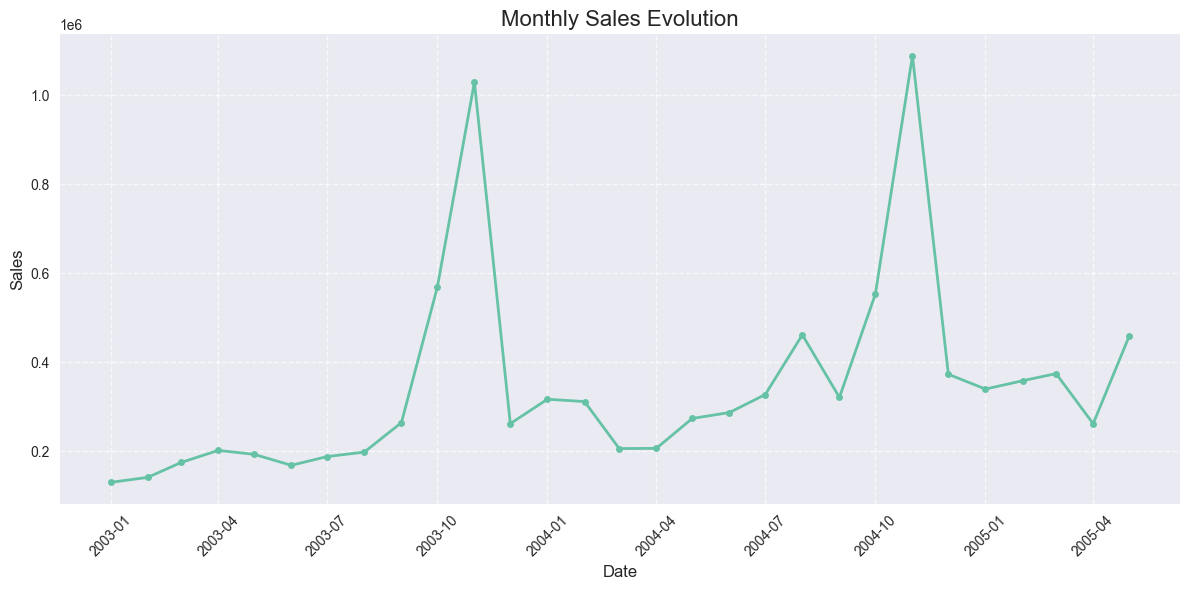

In [20]:
# 📈 Monthly Sales Trend

# Group sales by year and month
sales_by_month = df.groupby(['ORDER_YEAR', 'ORDER_MONTH'])['SALES'].sum()

# Create proper datetime index
sales_by_month.index = pd.to_datetime({
    'year': sales_by_month.index.get_level_values(0),
    'month': sales_by_month.index.get_level_values(1),
    'day': 1
})

# Sort index
sales_by_month = sales_by_month.sort_index()

# Plot
plt.figure(figsize=(12,6))
plt.plot(sales_by_month.index, sales_by_month.values, marker='o', linewidth=2, markersize=5)
plt.title('Monthly Sales Evolution', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Insights

- Sales exhibit a strong seasonal pattern, with significant peaks in November 2003 and 2004.
- These peaks may be linked to year-end campaigns, holidays, or client purchasing cycles.
- This seasonal effect must be considered if building forecasting models, to avoid bias or inaccurate generalizations.

#### 3.2.2 Seasonal Behavior by Product Line

#### Goal
Identify which product categories experience a sales surge in November,  
to support inventory planning and targeted marketing during seasonal peaks.

/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/4152381748.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  november_grouped = november_sales.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/4152381748.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rest_grouped = other_months.groupby('PRODUCTLINE')['SALES'].mean().sort_values(ascending=False)


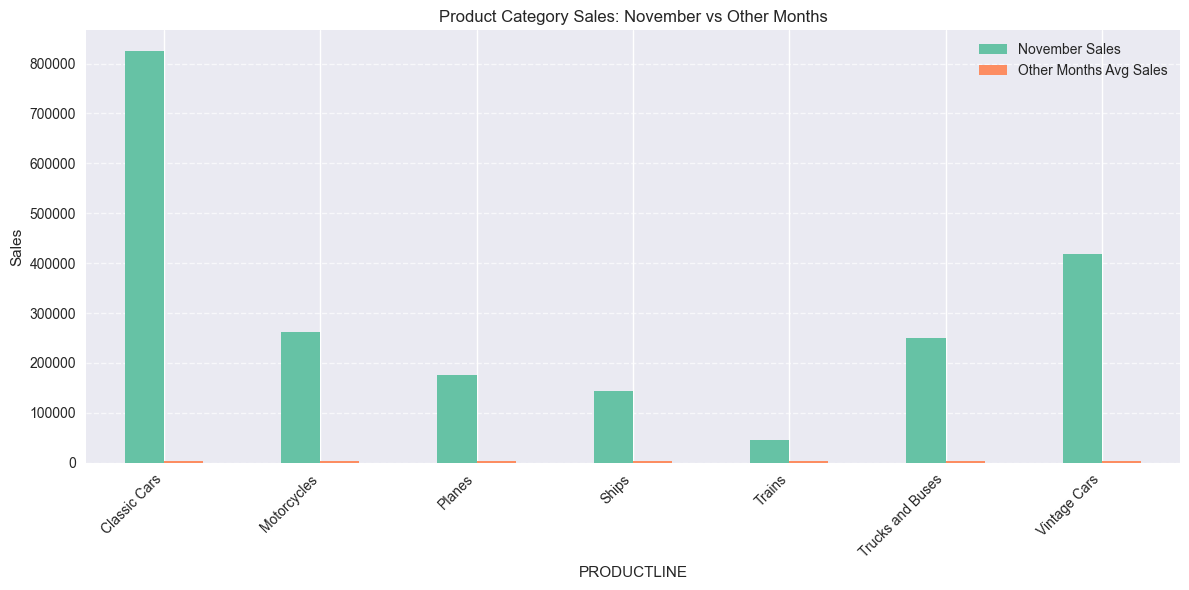

In [21]:
# Extraer mes y año si aún no están
df['ORDER_MONTH'] = df['ORDERDATE'].dt.month
df['ORDER_YEAR'] = df['ORDERDATE'].dt.year

# Filtrar solo noviembre
november_sales = df[df['ORDER_MONTH'] == 11]

# Agrupar ventas por categoría solo en noviembre
november_grouped = november_sales.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

# Agrupar ventas por categoría en el resto del año
other_months = df[df['ORDER_MONTH'] != 11]
rest_grouped = other_months.groupby('PRODUCTLINE')['SALES'].mean().sort_values(ascending=False)

# Crear dataframe combinado para comparar
comparison_df = pd.DataFrame({
    'November Sales': november_grouped,
    'Other Months Avg Sales': rest_grouped
}).dropna()

# Plot de comparación
comparison_df.plot(kind='bar', figsize=(12,6))
plt.title('Product Category Sales: November vs Other Months')
plt.ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Insights

- **Classic Cars** show an extreme increase in November, far exceeding their average performance in other months.  
  This suggests a strong seasonal buying pattern that should be supported with focused campaigns and stock planning.

- **Vintage Cars** and **Motorcycles** also benefit from seasonal demand, indicating that these segments could be ideal for promotional strategies targeting year-end shoppers.

- **Trains** show no meaningful seasonal variation, suggesting a stable but less responsive market segment.

- Understanding these patterns can help prioritize marketing spend, align production schedules, and anticipate inventory needs during high-impact months like November.

#### 3.2.3 Sales vs Profitability by Product Line

#### Goal
Evaluate whether the most sold product lines are also the most profitable,   
based on the ratio between sale price and MSRP (as an estimated profit margin).

This helps identify which categories deserve investment based not only on volume, but also margin performance.

/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/2553820319.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profitability_df = df.groupby('PRODUCTLINE').agg({
/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/2553820319.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(profitability_df.index, rotation=45, ha='right')


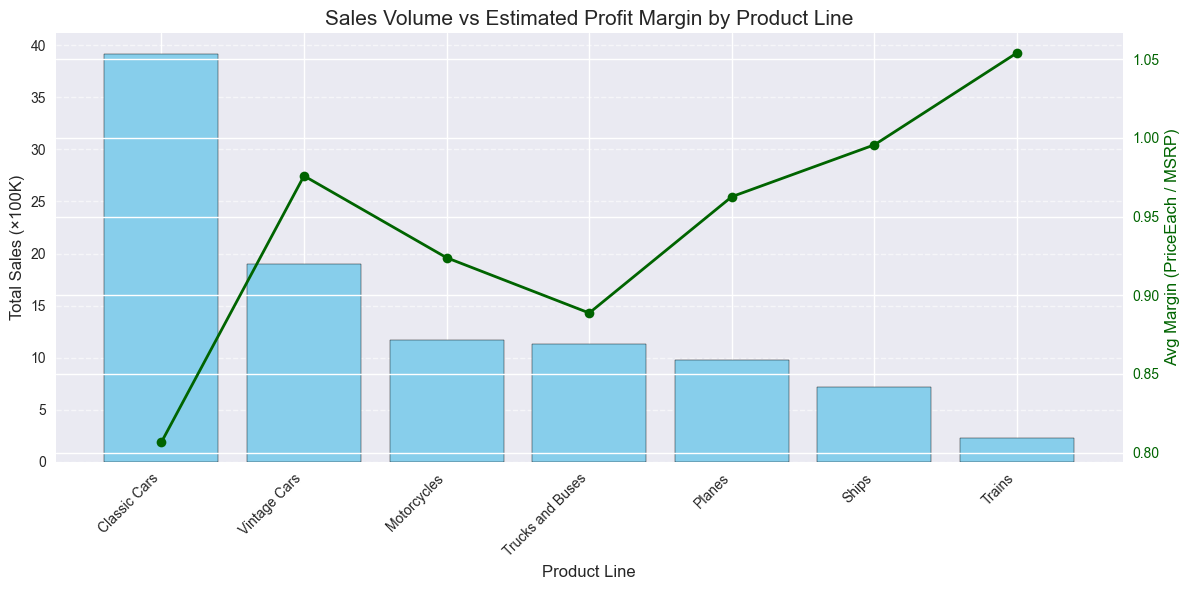

In [22]:
# 🧮 Estimate margin as the ratio between actual price and MSRP
df['ESTIMATED_MARGIN'] = df['PRICEEACH'] / df['MSRP']

# 📊 Aggregate total sales and average margin per product line
profitability_df = df.groupby('PRODUCTLINE').agg({
    'SALES': 'sum',
    'ESTIMATED_MARGIN': 'mean'
}).sort_values(by='SALES', ascending=False)

# 🔄 Scale sales for better visualization (in units of 100K)
profitability_df['SCALED_SALES'] = profitability_df['SALES'] / 1e5

# 📈 Create dual-axis chart: bar for sales, line for margin
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart for scaled sales
ax1.bar(profitability_df.index, profitability_df['SCALED_SALES'],
        color='skyblue', edgecolor='black', label='Total Sales (×100K)')
ax1.set_ylabel('Total Sales (×100K)', fontsize=12)
ax1.set_xlabel('Product Line', fontsize=12)
ax1.set_xticklabels(profitability_df.index, rotation=45, ha='right')
ax1.tick_params(axis='y')

# Line chart for average margin
ax2 = ax1.twinx()
ax2.plot(profitability_df.index, profitability_df['ESTIMATED_MARGIN'],
         marker='o', color='darkgreen', linewidth=2, label='Avg Estimated Margin')
ax2.set_ylabel('Avg Margin (PriceEach / MSRP)', fontsize=12, color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')

# 🧼 Chart aesthetics
plt.title('Sales Volume vs Estimated Profit Margin by Product Line', fontsize=15)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

#### Insights

- **Classic Cars** are top performers in volume but have the **lowest average margin**, indicating aggressive pricing or heavy discounting.  
  This may be acceptable if driven by strategic campaigns (e.g. seasonal offers), but should be monitored to avoid margin erosion.

- **Vintage Cars and Motorcycles** show a **balanced position** with both good volume and healthy margins — likely **star products** worth continued investment.

- **Trains**, despite low sales, have the **highest relative margin**, suggesting premium appeal.  
  Consider testing repositioning or bundling strategies to increase demand without sacrificing profitability.

- **Planes and Ships** have relatively high margins and moderate sales, indicating **profit-focused segments**.  
  These may benefit from targeted B2B efforts or luxury-positioned marketing.

- **Trucks and Buses** are trailing in both sales and margins, which may signal a need for product refresh, market repositioning, or bundling offers to boost performance.

#### 3.2.4 Average Order Size by Country

#### Goal
Identify which countries place the largest orders on average,  
to understand regional purchasing behavior and evaluate B2B opportunities or demand patterns.

This can inform regional campaign design, bundling strategies, or inventory prioritization.

/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/332401998.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders_by_country = df.groupby(['COUNTRY', 'ORDERNUMBER'])['QUANTITYORDERED'].sum()
/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/332401998.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_order_size = orders_by_country.groupby('COUNTRY').mean().sort_values(ascending=False)


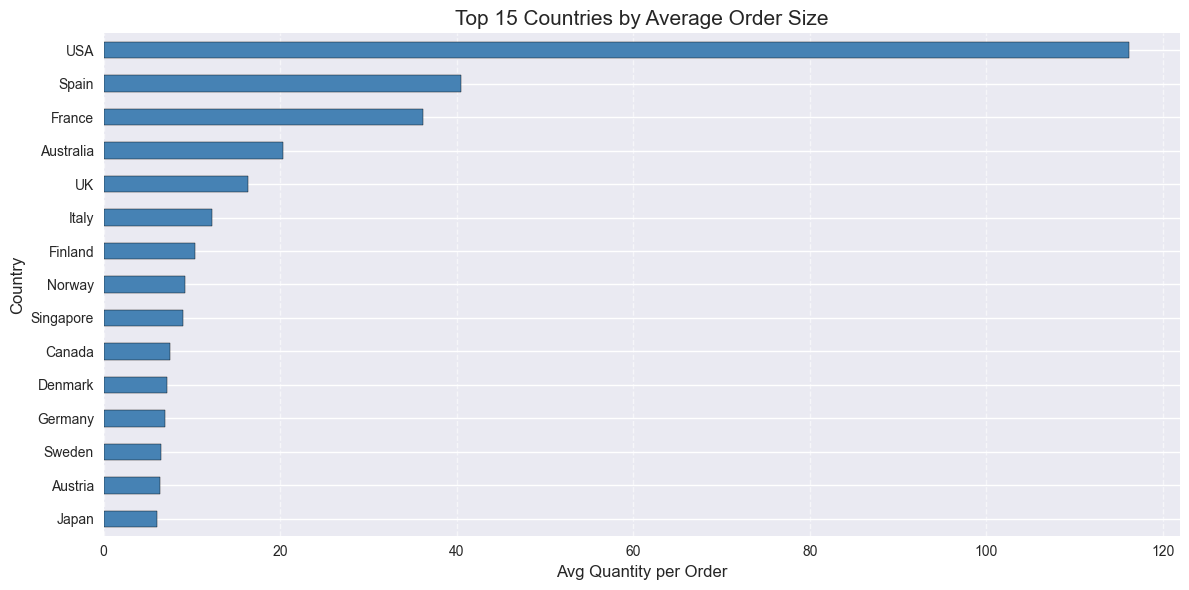

In [23]:
# 🧮 Group by COUNTRY and ORDERNUMBER to count items per order
orders_by_country = df.groupby(['COUNTRY', 'ORDERNUMBER'])['QUANTITYORDERED'].sum()

# 🧮 Compute average order size per country
average_order_size = orders_by_country.groupby('COUNTRY').mean().sort_values(ascending=False)

# 📊 Plot top 15 countries by average order size
plt.figure(figsize=(12,6))
average_order_size.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Countries by Average Order Size', fontsize=15)
plt.xlabel('Avg Quantity per Order', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.gca().invert_yaxis()  # Largest at top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Insights

- The **United States** exhibits an extraordinarily high average order size (>110 units per order),  
  suggesting the presence of **bulk buyers**, **resellers**, or **logistics hubs**.  
  This presents opportunities for **volume-based pricing**, **exclusive B2B partnerships**, and **tailored fulfillment strategies**.

- **Spain and France** also demonstrate high average order volumes, indicating potential for regional B2B targeting or large client campaigns.

- Countries with moderate order sizes (e.g., UK, Australia, Italy) may benefit from **standardized bundles** or **upselling techniques**.

- Smaller average order sizes in **Nordic countries and Japan** suggest either a fragmented customer base or retail-oriented behavior,  
  where **personalized recommendations** or **free shipping thresholds** might be more effective than bulk promotions.

#### 3.2.5 Customer Sales Concentration

#### Goal
Assess the revenue concentration among customers to determine business dependency and  
identify top clients that drive the majority of total sales.

#### Method
We calculated cumulative sales contribution by customer rank to identify concentration patterns.

#### What to Look For
- How many customers account for 80% of total sales?
- Does the business follow a classic 80/20 rule?
- Which clients warrant prioritized relationship management or upselling efforts?

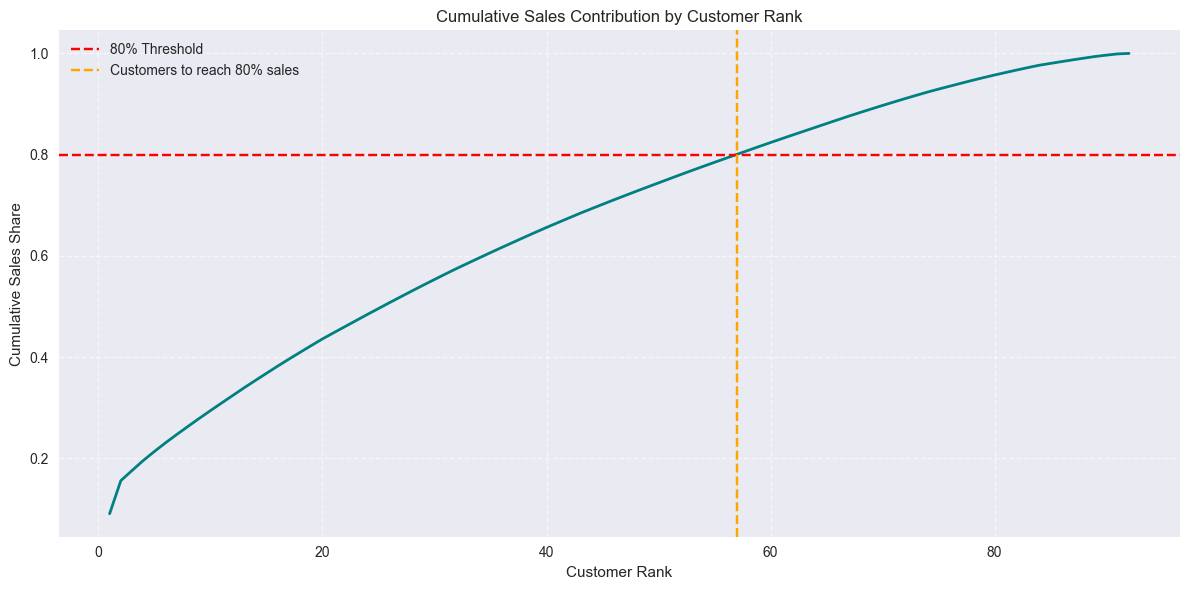

In [24]:
# 📊 Total sales per customer
customer_sales = df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False)

# 📈 Cumulative percentage of sales
cumulative_sales = customer_sales.cumsum() / customer_sales.sum()

# 🧮 Add rank and percentage
customer_rank_df = customer_sales.reset_index().rename(columns={'SALES': 'TOTAL_SALES'})
customer_rank_df['CUMULATIVE_SHARE'] = cumulative_sales.values
customer_rank_df['RANK'] = range(1, len(customer_rank_df)+1)

# 📈 Plot cumulative sales share
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(customer_rank_df['RANK'], customer_rank_df['CUMULATIVE_SHARE'], color='teal', linewidth=2)
plt.axhline(0.8, color='red', linestyle='--', label='80% Threshold')
plt.axvline(customer_rank_df[customer_rank_df['CUMULATIVE_SHARE'] >= 0.8].iloc[0]['RANK'],
            color='orange', linestyle='--', label='Customers to reach 80% sales')
plt.title('Cumulative Sales Contribution by Customer Rank')
plt.xlabel('Customer Rank')
plt.ylabel('Cumulative Sales Share')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#### Insights

- The business does **not follow a classic 80/20 pattern** — it takes ~57 customers to reach 80% of total sales.
- This indicates a **well-distributed revenue base**, reducing dependency on a few key clients and improving revenue stability.
- However, it also suggests **fewer ultra-high-value accounts**, and thus may require broader engagement strategies.
- Relationship management should be expanded to cover the **top 50–60 clients**, with tailored communication, cross-selling, and loyalty initiatives.

#### 3.2.6 Price vs Quantity Ordered

#### Goal
Evaluate whether there is an inverse relationship between product price and quantity ordered.  
This helps understand customer price sensitivity, and whether bulk purchases are driven by lower-priced items.

#### What to Look For
- Clear downward trend: strong price sensitivity.
- Cluster of low-price/high-quantity items: candidate for bundles or volume discounts.
- Outliers: high-price items still sold in volume (possibly to B2B clients or luxury buyers).

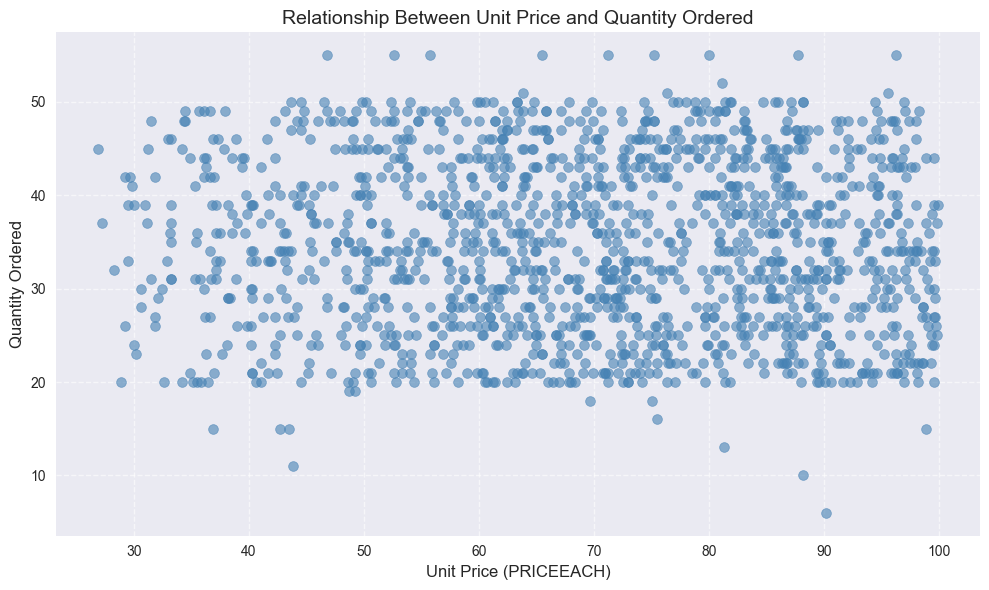

In [25]:
# Extreme outliers were removed for clearer visualization
filtered_df = df[(df['PRICEEACH'] < df['PRICEEACH'].quantile(0.99)) & 
                 (df['QUANTITYORDERED'] < df['QUANTITYORDERED'].quantile(0.99))]

# 📉 Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=filtered_df, 
    x='PRICEEACH', 
    y='QUANTITYORDERED', 
    alpha=0.6, 
    edgecolor=None,
    color='steelblue'
)

plt.title('Relationship Between Unit Price and Quantity Ordered', fontsize=14)
plt.xlabel('Unit Price (PRICEEACH)', fontsize=12)
plt.ylabel('Quantity Ordered', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#### Insights

- The scatter plot indicates **no significant inverse relationship** between unit price and quantity ordered.
- This implies a **low price elasticity**: customers are not necessarily buying fewer units of high-priced items.
- Therefore, **discounting strategies may not be necessary** to drive volume, especially for higher-end products.
- The observed behavior supports maintaining **premium pricing** without fearing a drop in demand, particularly for products already selling well at higher price points.
- Additional segmentation by product line or customer type could reveal more nuanced patterns and validate whether this applies uniformly across the catalog.


#### 3.2.7 Price Sensitivity by Product Line

#### Goal
Explore the relationship between unit price and quantity ordered, segmented by product line,  
to uncover differentiated behaviors and identify lines with high or low price sensitivity.

This allows for more tailored pricing and promotion strategies per segment.

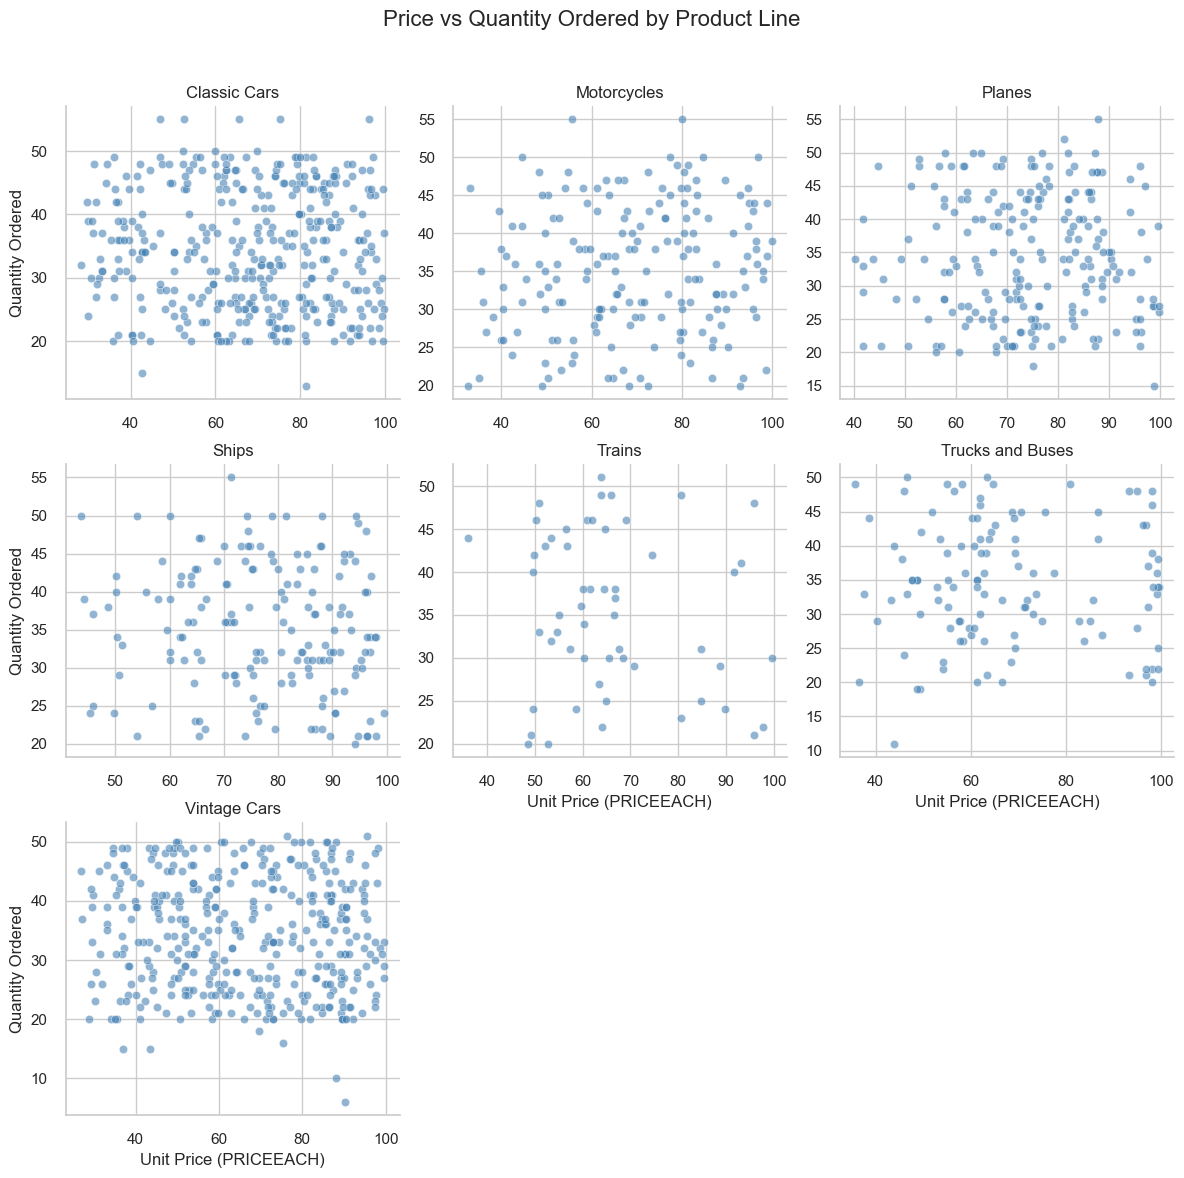

In [26]:
# filter out extreme outliers
filtered_df = df[(df['PRICEEACH'] < df['PRICEEACH'].quantile(0.99)) & 
                 (df['QUANTITYORDERED'] < df['QUANTITYORDERED'].quantile(0.99))]

# Set plot style
sns.set(style='whitegrid')

# Create subplots: one for each product line
g = sns.FacetGrid(
    data=filtered_df, 
    col='PRODUCTLINE', 
    col_wrap=3, 
    height=4, 
    sharex=False, 
    sharey=False
)

# Add scatterplots
g.map_dataframe(
    sns.scatterplot, 
    x='PRICEEACH', 
    y='QUANTITYORDERED', 
    alpha=0.6, 
    color='steelblue'
)

g.set_titles('{col_name}')
g.set_axis_labels('Unit Price (PRICEEACH)', 'Quantity Ordered')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Price vs Quantity Ordered by Product Line', fontsize=16)
plt.show()

#### Insights

- **Classic and Vintage Cars** show **very stable purchase volumes** across the price spectrum, indicating **low price sensitivity** and strong brand pull. These products are ideal for **premium positioning**, minimal discounting, and high-margin campaigns.

- **Planes** show mild signs of price sensitivity, with quantity ordered slightly decreasing at higher prices. Consider **price tiering** or **value-added packages** to protect volume.

- **Trains and Ships** demonstrate sparse and low-volume behavior. These segments might benefit from **exclusive positioning**, or could indicate a **need for relaunch or rebranding** due to low demand.

- **Motorcycles and Trucks/Buses** display more variation and inconsistency. These may respond well to **strategic bundling**, **volume-based incentives**, or **localized pricing experiments** to uncover what drives conversions.
---

## 🤖 4. Demand Forecasting Model

### 4.1 Objective

The goal of this section is to develop a predictive model capable of estimating monthly sales volume  
based on historical trends, product categories, and key business features. 
 
This type of model is commonly used for **demand forecasting**, **inventory planning**, and **strategic decision-making** in retail and supply chain environments.

### 4.2 Problem Framing

We define this as a **supervised regression task**, where the target variable is:
- `SALES` – total monthly sales per product category

The prediction will be based on several features, including:
- `ORDER_YEAR` and `ORDER_MONTH` – temporal context
- `PRODUCTLINE` – product category
- `AVG_QUANTITY` – average quantity ordered
- `AVG_MARGIN` – average ratio between actual price and MSRP (proxy for profitability)

### 4.3 Data Preparation

We aggregate the dataset at a **monthly and product line level**,  
calculating total sales, average quantity ordered, and average estimated margin for each group.

A new `DATE` column is also created to support time-based features or future use in time series forecasting models.

The resulting dataset is now ready for:

- **Model training and evaluation**
- **Feature encoding and scaling (if needed)**
- **Interpretation of predictions for business impact**

In [27]:
# 🧮 Step 1: Feature engineering (re-ensure needed columns exist)
df['ORDER_YEAR'] = df['ORDERDATE'].dt.year
df['ORDER_MONTH'] = df['ORDERDATE'].dt.month
df['ESTIMATED_MARGIN'] = df['PRICEEACH'] / df['MSRP']

# 🧩 Step 2: Aggregate sales by PRODUCTLINE, MONTH, and YEAR
df_model = df.groupby(['PRODUCTLINE', 'ORDER_YEAR', 'ORDER_MONTH']).agg({
    'SALES': 'sum',
    'QUANTITYORDERED': 'mean',
    'ESTIMATED_MARGIN': 'mean'
}).reset_index()

# Rename for clarity
df_model.rename(columns={
    'QUANTITYORDERED': 'AVG_QUANTITY',
    'ESTIMATED_MARGIN': 'AVG_MARGIN'
}, inplace=True)

# 📅 Step 3: Create a datetime column for future time-series modeling
df_model['DATE'] = pd.to_datetime({
    'year': df_model['ORDER_YEAR'],
    'month': df_model['ORDER_MONTH'],
    'day': 1
})

/var/folders/j1/pdsb5w0x52sgplylm6f7fmgm0000gn/T/ipykernel_12975/2031935597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model = df.groupby(['PRODUCTLINE', 'ORDER_YEAR', 'ORDER_MONTH']).agg({


In [29]:
# Let's check the first 10 rows of the final model dataframe 
print(df_model.head(10))
# Save the cleaned and processed DataFrame to a new CSV file
output_path = '../data/superstore_sales_modeled.csv'
df_model.to_csv(output_path, index=False)
print(f"Cleaned and processed data saved to {output_path}")

    PRODUCTLINE  ORDER_YEAR  ORDER_MONTH      SALES  AVG_QUANTITY  AVG_MARGIN  \
0  Classic Cars        2003            1   41191.78     33.400000    0.765682   
1  Classic Cars        2003            2   20464.41     40.000000    0.598807   
2  Classic Cars        2003            3  105026.68     35.730769    0.831486   
3  Classic Cars        2003            4   59873.60     38.750000    0.746393   
4  Classic Cars        2003            5   98179.48     33.357143    0.805033   
5  Classic Cars        2003            6   50256.79     33.800000    0.734101   
6  Classic Cars        2003            7   94055.58     34.772727    0.809288   
7  Classic Cars        2003            8   48406.61     33.900000    0.733049   
8  Classic Cars        2003            9  137666.87     30.783784    0.813641   
9  Classic Cars        2003           10  241145.43     32.774194    0.829747   

        DATE  
0 2003-01-01  
1 2003-02-01  
2 2003-03-01  
3 2003-04-01  
4 2003-05-01  
5 2003-06-01  
6 2

### 4.4 Model Training and Evaluation

We used a Random Forest Regressor to predict monthly sales per product line.  
The model will be trained using 80% of the dataset and evaluated on the remaining 20%.

#### Features used:
- `ORDER_YEAR`, `ORDER_MONTH` – for seasonality and trend
- `PRODUCTLINE` (one-hot encoded)
- `AVG_QUANTITY` – purchase behavior
- `AVG_MARGIN` – pricing strategy indicator

#### Metrics:
- **MAE (Mean Absolute Error)**: average absolute prediction error
- **RMSE (Root Mean Squared Error)**: penalizes large errors more
- **R² Score**: proportion of variance explained by the model

In [31]:
# Step 1: Feature encoding and selection
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Select features and target
features = ['ORDER_YEAR', 'ORDER_MONTH', 'PRODUCTLINE', 'AVG_QUANTITY', 'AVG_MARGIN']
target = 'SALES'

# One-hot encode PRODUCTLINE
df_encoded = pd.get_dummies(df_model[features], columns=['PRODUCTLINE'], drop_first=True)

# Final feature matrix (X) and target vector (y)
X = df_encoded
y = df_model[target]

# Step 2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train a Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 4: Model Evaluation
y_pred = rf_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R²:   {r2:.4f}')

MAE:  21,783.18
RMSE: 46,255.22
R²:   0.6719


### 4.5 Evaluation of Forecast Model

The Random Forest Regressor was able to explain approximately **67% of the variance** in monthly sales values,  
with a mean absolute error of **~$21.8K**. This level of performance is considered acceptable for high-level demand  
forecasting at the product category level.

The model successfully captures seasonal patterns, product line performance differences, and pricing behavior       
signals through features such as average order size and average margin.

This forecast can support:
- Monthly production and inventory planning
- Financial scenario simulations
- Budget allocation by product line or territory

Future improvements could include:
- Integrating external variables (e.g. promotions, holidays, economic indicators)
- Applying models tailored for time series (e.g. Prophet, XGBoost, or SARIMA)
---

### 4.6 Model Optimization and Comparison

To improve performance, we engineered new features:
- **SEASON**: Quarter of the year (Q1–Q4)
- **IS_HOLIDAY_SEASON**: Flag for November and December
- **IS_HIGH_MARGIN**: Flag for margin > 0.9

We then:
- Tuned a Random Forest model using GridSearchCV
- Benchmarked results using XGBoost

Final metrics (MAE, RMSE, R²) were used to compare models and select the best for strategic recommendation.

In [32]:
# 1. Season (quarter)
df_model['SEASON'] = pd.cut(
    df_model['ORDER_MONTH'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# 2. Holiday Season flag (November/December)
df_model['IS_HOLIDAY_SEASON'] = df_model['ORDER_MONTH'].isin([11, 12]).astype(int)

# 3. High Margin flag (based on threshold)
df_model['IS_HIGH_MARGIN'] = (df_model['AVG_MARGIN'] > 0.9).astype(int)

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features and target
features = ['ORDER_YEAR', 'ORDER_MONTH', 'AVG_QUANTITY', 'AVG_MARGIN',
            'IS_HOLIDAY_SEASON', 'IS_HIGH_MARGIN', 'SEASON', 'PRODUCTLINE']
target = 'SALES'

# One-hot encoding for categorical columns
categorical = ['SEASON', 'PRODUCTLINE']
numeric = ['ORDER_YEAR', 'ORDER_MONTH', 'AVG_QUANTITY', 'AVG_MARGIN', 'IS_HOLIDAY_SEASON', 'IS_HIGH_MARGIN']

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

# Define pipeline
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [ ]:
# Define hyperparameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 6, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Train/test split
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_rf_model = grid_search.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


In [35]:
# Evaluate best model
y_pred = best_rf_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print results
print(f'Best Parameters: {grid_search.best_params_}')
print(f'MAE:  {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R²:   {r2:.4f}')

Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
MAE:  22,396.65
RMSE: 47,780.45
R²:   0.6499


In [36]:
from xgboost import XGBRegressor

# Same pipeline but with XGBoost
pipeline_xgb = Pipeline([
    ('prep', preprocessor),
    ('model', XGBRegressor(objective='reg:squarederror', random_state=42))
])

pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)

# Metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'[XGBoost] MAE:  {mae_xgb:,.2f}')
print(f'[XGBoost] RMSE: {rmse_xgb:,.2f}')
print(f'[XGBoost] R²:   {r2_xgb:.4f}')

[XGBoost] MAE:  21,647.61
[XGBoost] RMSE: 38,440.00
[XGBoost] R²:   0.7734


### 4.7 Final Model Evaluation and Selection

After implementing feature engineering and hyperparameter tuning,  
we compared the performance of a tuned Random Forest and XGBoost model.

#### Final Results:

| Model         | MAE     | RMSE    | R²     |
|---------------|---------|---------|--------|
| Random Forest | 22,396  | 47,780  | 0.6499 |
| XGBoost       | 21,647  | 38,440  | 0.7734 |

XGBoost emerged as the best-performing model, achieving a significant increase in explained variance (R² = 77.34%)  
and reducing overall prediction errors. This makes it suitable for monthly sales forecasting across product lines  
and for use in operational planning scenarios.